<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Visión por Computadora II
## Detección en imágenes fisheye: rama 1, baseline

### Objetivo

Esta rama es la celda "sin rectificar, sin fine-tuning" del factorial 2×2. Corro YOLO26m pre-entrenado en COCO directamente sobre las imágenes fisheye de WoodScape, sin tocar ni la imagen ni el modelo. El resultado es la referencia contra la que se comparan las otras tres ramas:

| | sin fine-tuning | con fine-tuning |
|---|---|---|
| **sin rectificar** | **Rama 1 (este notebook)** | Rama 3 |
| **rectificado** | Rama 2 | Rama 4 |

La pregunta que contesta es cuánto se degrada un detector estándar hacia la periferia de la lente. Mido mAP@50 y mAP@50-95 global, estratificados por ángulo de incidencia θ con los cortes congelados del equipo (68,3° y 80,7°), por clase, el cruce anillo × tamaño de objeto y la latencia.

![flujo](../vpc2_fisheye.png)

### Imports y constantes

In [1]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import json
import sys
import time
from functools import partial
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import supervision as sv
import torch
import ultralytics
from tqdm.auto import tqdm

tqdm = partial(tqdm, mininterval=30)  # sin esto la barra deja miles de lineas en el notebook guardado

# las funciones compartidas por todas las ramas estan en fisheye_utils.py, en la raiz del repo
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from fisheye_utils import (
    ANILLOS_THETA, CLASES, CONF, DEVICE, IMGSZ, MODELOS, NOMBRES_ANILLOS,
    a_clases_tp, cargar_test, dibujar, evaluar, radio, tabla_resultados, theta,
)

C:\Users\tadeo\workspace\vision-computadora-II-tp-final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SALIDAS = RAIZ / "outputs/rama1"
SALIDAS.mkdir(parents=True, exist_ok=True)
MODELO = "yolo26m"  # acordado para las cuatro ramas (regla 6)
N_IMAGENES = None  # un entero para pruebas rapidas, None para todo el test

gpu = torch.cuda.get_device_name(0) if DEVICE == "cuda" else DEVICE
print(f"device: {DEVICE} ({gpu}) | torch {torch.__version__} | ultralytics {ultralytics.__version__} | supervision {sv.__version__}")
print(f"modelo: {MODELO} | imgsz: {IMGSZ} | conf: {CONF}")

device: cuda (NVIDIA GeForce RTX 4080 SUPER) | torch 2.11.0+cu128 | ultralytics 8.4.164 | supervision 0.30.5
modelo: yolo26m | imgsz: 640 | conf: 0.01


### Carga del test y ground truth

Uso las 1000 imágenes de test del Drive del equipo, idénticas para las cuatro ramas. El ground truth lo arma `cargar_test` con las mismas funciones de `convert_to_yolo.py` y el mismo `class_map.json` (caja = mínimo y máximo del polígono, descartando las de menos de 300 px² o con un lado menor a 8 px). Si el test está completo, `cargar_test` verifica que sean las 11.910 cajas de control.

In [3]:
test = cargar_test(N_IMAGENES)
print(f"clases: {CLASES} | cajas de gt: {sum(len(c) for c in test['gt_clases'])}")

pd.DataFrame({
    "imagenes": test.groupby("camera").size(),
    **{c: test.groupby("camera")["gt_clases"].apply(lambda s, i=i: sum((x == i).sum() for x in s)) for i, c in enumerate(CLASES)},
})

test: 1000 imagenes en el manifest | presentes: 1000 | faltan 0


clases: ['vehicle', 'person', 'two_wheeler'] | cajas de gt: 11910


,imagenes,vehicle,person,two_wheeler
camera,,,,
FV,247,1351,747,640
MVL,251,2080,611,502
MVR,261,1635,779,808
RV,241,1456,649,652


### Ángulo de incidencia

La deformación de la fisheye depende del ángulo θ entre el rayo y el eje óptico, no de la distancia en píxeles. Para cada caja tomo su centro, calculo su distancia al centro óptico (corrigiendo por `aspect_ratio`) y obtengo θ invirtiendo numéricamente el polinomio de la calibración, `rho(θ) = k1·θ + k2·θ² + k3·θ³ + k4·θ⁴`. Lo hace `theta` en `fisheye_utils.py`.

Los cortes de anillo están congelados en 68,3° y 80,7° (`rings.json`), que son los terciles de la distribución de θ del ground truth. Como chequeo, cada anillo tendría que quedar con unas 3970 cajas. Si da muy distinto, el cálculo de θ no coincide con el del evaluador del equipo.

centro       3970
medio        3970
periferia    3970
Name: count, dtype: int64
theta del gt: mediana 75.6 | max 96.1 grados


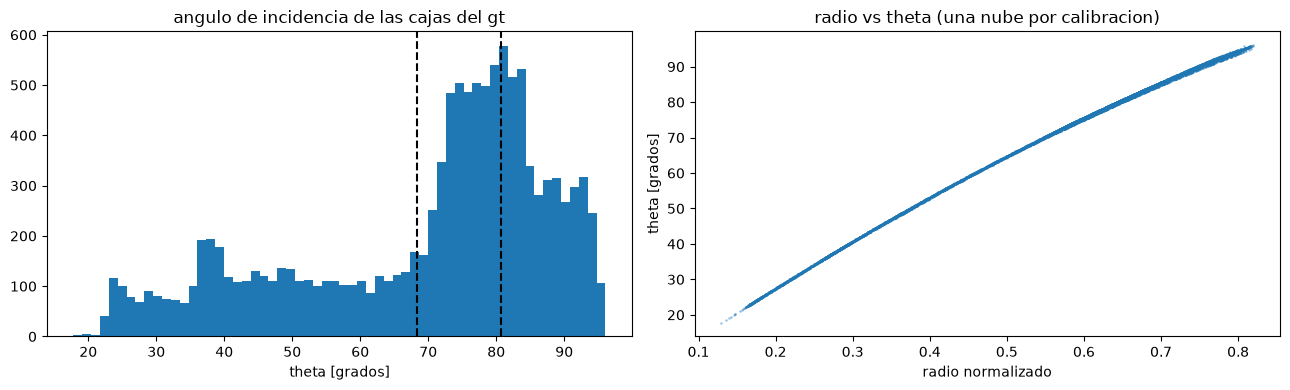

In [4]:
th_gt = np.concatenate([theta(f.gt_cajas, f) for f in test.itertuples()])
r_gt = np.concatenate([radio(f.gt_cajas, f) for f in test.itertuples()])
print(pd.cut(th_gt, ANILLOS_THETA, labels=NOMBRES_ANILLOS, right=False).value_counts().sort_index())
print(f"theta del gt: mediana {np.median(th_gt):.1f} | max {th_gt.max():.1f} grados")

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].hist(th_gt, bins=60)
for c in ANILLOS_THETA[1:-1]:
    axs[0].axvline(c, color="k", ls="--")
axs[0].set_xlabel("theta [grados]")
axs[0].set_title("angulo de incidencia de las cajas del gt")
axs[1].scatter(r_gt, th_gt, s=1, alpha=0.3)
axs[1].set_xlabel("radio normalizado")
axs[1].set_ylabel("theta [grados]")
axs[1].set_title("radio vs theta (una nube por calibracion)")
plt.tight_layout()
plt.savefig(SALIDAS / "theta_gt.png", dpi=150)
plt.show()

### Modelo

YOLO26m de Ultralytics, pre-entrenado en COCO, sin ninguna modificación. Traduzco sus clases a las del TP y descarto el resto:

| COCO | TP |
|---|---|
| car, bus, truck | vehicle |
| person | person |
| bicycle, motorcycle | two_wheeler |

Uso `imgsz=640` y el umbral de confianza bajo de `fisheye_utils` (`CONF`): el mAP necesita la cola de baja confianza para armar la curva precisión-recall (regla 5).

### Inferencia sobre todo el test

Por cada imagen mido en milisegundos:
* inf: el detector completo, con su resize, NMS y la copia a CPU. La copia obliga a esperar a que la GPU termine, así que el tiempo incluye todo el cómputo.
* post: filtrar y traducir las clases.

No hay preprocesamiento: esta rama no transforma la imagen. La lectura del disco queda afuera de la medición, igual que en la rama 2. Antes de medir hago diez pasadas de calentamiento. Las predicciones se guardan en `outputs/rama1/` para no repetir la corrida si se reinicia el kernel.

In [5]:
def predecir(nombre):
    """corre un modelo sobre todo el test y devuelve un dataframe con cajas y tiempos por imagen"""
    ruta = SALIDAS / f"preds_{nombre}_{len(test)}.pkl"
    if ruta.exists():
        return pd.read_pickle(ruta)
    detectar, coco = MODELOS[nombre]()
    img0 = cv2.imread(str(test.iloc[0].ruta))
    for _ in range(10):
        detectar(img0)

    filas = []
    for fila in tqdm(test.itertuples(), total=len(test), desc=nombre):
        img = cv2.imread(str(fila.ruta))
        t0 = time.perf_counter()
        xyxy, conf, cls = detectar(img)
        t1 = time.perf_counter()
        xyxy, conf, cls = a_clases_tp(xyxy, conf, cls, coco)
        t2 = time.perf_counter()
        filas.append({"stem": fila.stem, "cajas": xyxy, "conf": conf, "clases": cls,
                      "ms_inf": 1e3 * (t1 - t0), "ms_post": 1e3 * (t2 - t1)})
    preds = pd.DataFrame(filas)
    preds.to_pickle(ruta)
    return preds


preds = {MODELO: predecir(MODELO)}
p = preds[MODELO]
print(f"detecciones: {sum(len(c) for c in p['clases'])} | latencia media: {p['ms_inf'].mean():.1f} ms inf + {p['ms_post'].mean():.2f} ms post")

yolo26m:   0%|          | 0/1000 [00:00<?, ?it/s]

yolo26m: 100%|██████████| 1000/1000 [00:25<00:00, 38.74it/s]

detecciones: 52004 | latencia media: 11.7 ms inf + 0.10 ms post


Exporto también las predicciones en un json plano (una entrada por caja, en coordenadas de la fisheye y con los ids del TP) para que cualquiera pueda evaluarlas con otro script sin depender del pickle.

In [6]:
registros = [{"image": s, "bbox_xyxy": [round(float(v), 2) for v in c], "score": round(float(sc), 5), "class_id": int(k)}
             for s, cs, scs, ks in zip(p["stem"], p["cajas"], p["conf"], p["clases"]) for c, sc, k in zip(cs, scs, ks)]
(SALIDAS / f"pred_{MODELO}.json").write_text(json.dumps(registros))
print(f"{len(registros)} cajas en {SALIDAS / f'pred_{MODELO}.json'}")

52004 cajas en C:\Users\tadeo\workspace\vision-computadora-II-tp-final\outputs\rama1\pred_yolo26m.json


### Visualización

Una imagen por cámara, el ground truth a la izquierda y las detecciones a la derecha. Uso un umbral de 0,3 solo para que el dibujo se lea. Las métricas usan todas las cajas.

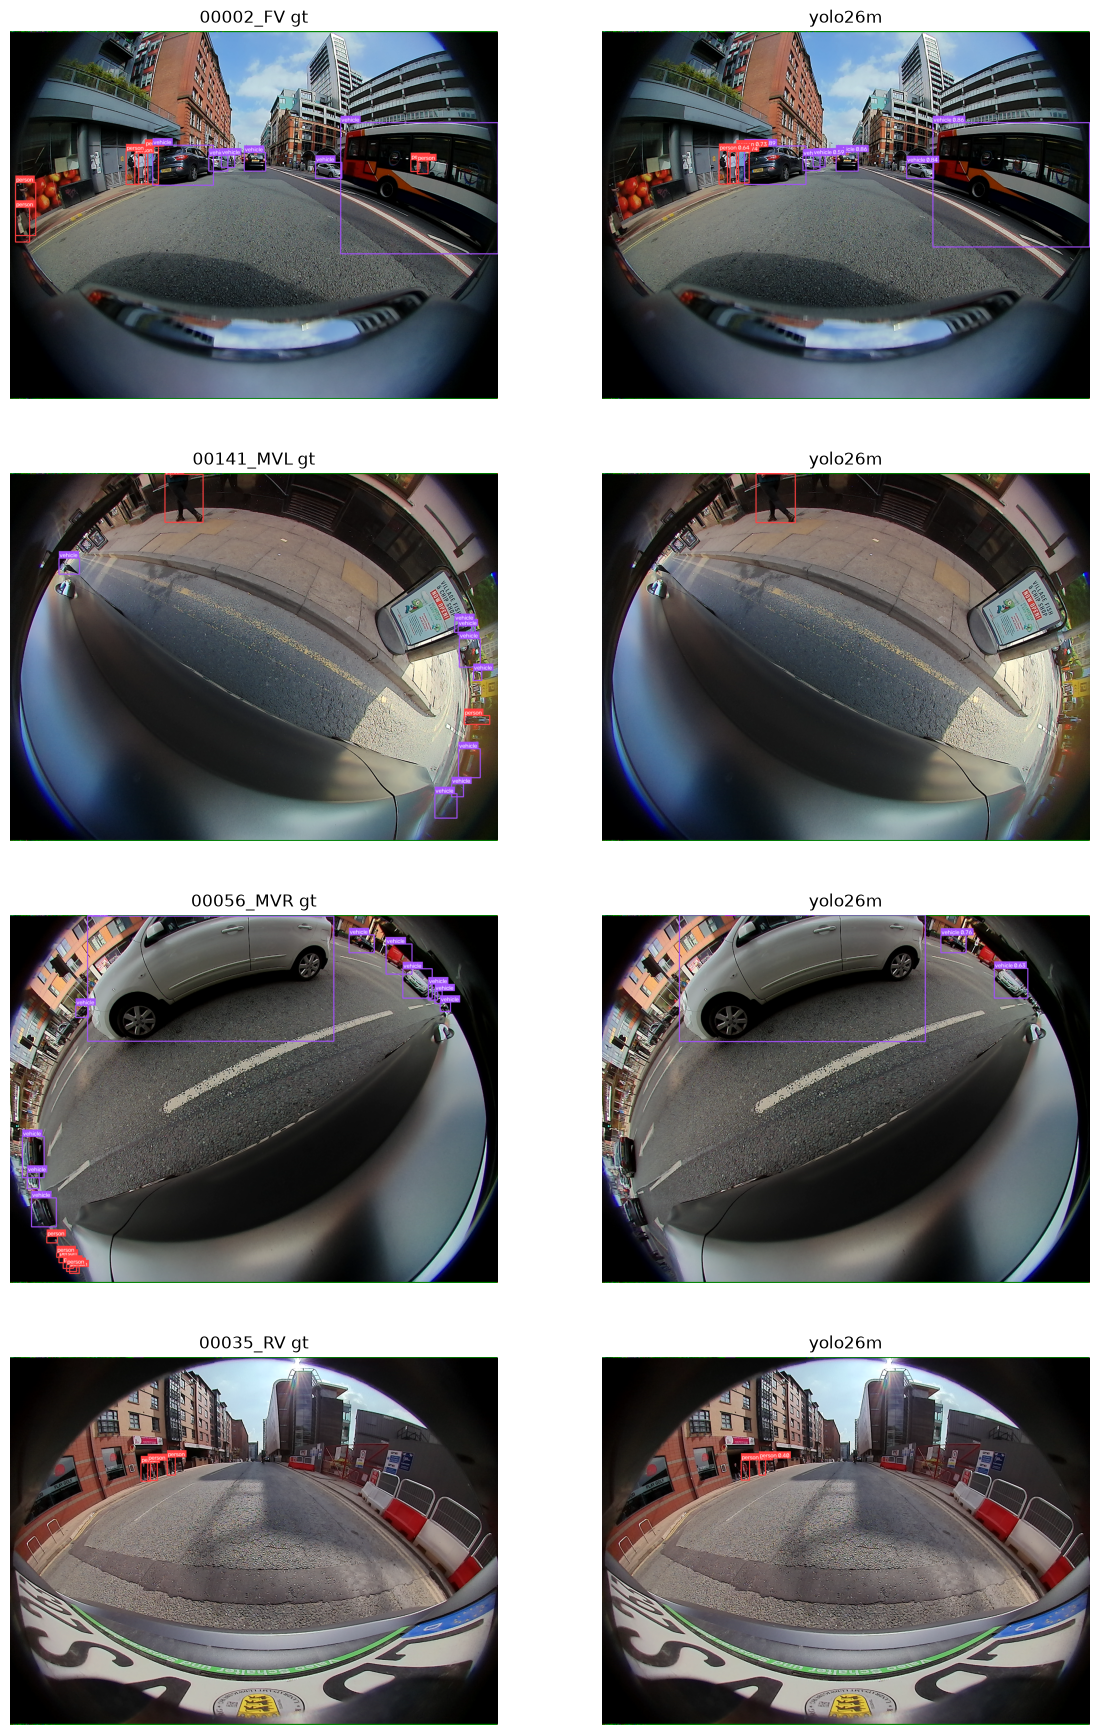

In [7]:
CONF_VIS = 0.3
pv = p.set_index("stem")


def paneles(fila, q):
    """gt | prediccion, sobre la fisheye"""
    img = cv2.imread(str(fila.ruta))
    m = q["conf"] >= CONF_VIS
    return [dibujar(img, fila.gt_cajas, fila.gt_clases), dibujar(img, q["cajas"][m], q["clases"][m], q["conf"][m])]


ejemplos = test.groupby("camera").head(1)
imgs, titulos = [], []
for fila in ejemplos.itertuples():
    imgs += paneles(fila, pv.loc[fila.stem])
    titulos += [f"{fila.stem} gt", f"{MODELO}"]
sv.plot_images_grid(imgs, grid_size=(4, 2), titles=titulos, size=(14, 22))

In [8]:
(SALIDAS / "vis").mkdir(exist_ok=True)
for fila in test.iloc[::50].itertuples():
    cv2.imwrite(str(SALIDAS / "vis" / f"{fila.stem}_{MODELO}.jpg"), np.hstack(paneles(fila, pv.loc[fila.stem])))
print(f"guardadas {len(test.iloc[::50])} imagenes en {SALIDAS / 'vis'}")

guardadas 20 imagenes en C:\Users\tadeo\workspace\vision-computadora-II-tp-final\outputs\rama1\vis


### Métricas

Uso `MeanAveragePrecision` de supervision (mAP@50 y mAP@50-95 estilo COCO) a través de `evaluar` de `fisheye_utils.py`, la misma función que usa la rama 2. Antes de confiar en los números pruebo con el propio ground truth como predicción: tiene que dar 1.

La tabla principal estratifica por θ (`por="theta"`), que es la métrica del paper. Agrego también la versión por radio normalizado (`por="radio"`), que es la que reporta hoy el notebook de la rama 2, para poder comparar directamente.

In [9]:
gt_como_pred = pd.DataFrame({"stem": test["stem"], "cajas": test["gt_cajas"], "clases": test["gt_clases"],
                             "conf": [np.ones(len(c), dtype=np.float32) for c in test["gt_clases"]]})
m50, m5095 = evaluar(gt_como_pred, test)
assert m50 > 0.99 and m5095 > 0.99, (m50, m5095)
print(f"gt vs gt: map50={m50:.3f} | map50-95={m5095:.3f}")

gt vs gt: map50=1.000 | map50-95=1.000


In [10]:
def por_anillo(p, filas, por="theta"):
    """tabla anillo x (n_gt, map50, map50-95), con la fila global al final"""
    medida = theta if por == "theta" else radio
    v = np.concatenate([medida(f.gt_cajas, f) for f in filas.itertuples()])
    cortes = ANILLOS_THETA if por == "theta" else [0, 1 / 3, 2 / 3, 1.0]
    filas_t = []
    for i, a in enumerate(NOMBRES_ANILLOS):
        m50, m5095 = evaluar(p, filas, anillo=i, por=por)
        filas_t.append({"anillo": a, "n_gt": int(((v >= cortes[i]) & (v < cortes[i + 1])).sum()), "mAP50": m50, "mAP50-95": m5095})
    m50, m5095 = evaluar(p, filas)
    filas_t.append({"anillo": "global", "n_gt": len(v), "mAP50": m50, "mAP50-95": m5095})
    return pd.DataFrame(filas_t).set_index("anillo")


res_theta = por_anillo(p, test, "theta")
res_theta.to_csv(SALIDAS / f"metricas_theta_{MODELO}.csv")
caida = 1 - res_theta.loc["periferia", "mAP50"] / res_theta.loc["centro", "mAP50"]
print(f"caida de mAP@50 centro -> periferia: {caida:.0%}")
res_theta.round(4)

caida de mAP@50 centro -> periferia: 69%


,n_gt,mAP50,mAP50-95
anillo,,,
centro,3970,0.5469,0.3605
medio,3970,0.4534,0.2951
periferia,3970,0.1712,0.1021
global,11910,0.3944,0.2522


In [11]:
res_radio = por_anillo(p, test, "radio")
res_radio.to_csv(SALIDAS / f"metricas_radio_{MODELO}.csv")
res_radio.round(4)

,n_gt,mAP50,mAP50-95
anillo,,,
centro,1887,0.5344,0.3495
medio,6656,0.4712,0.3051
periferia,3367,0.1571,0.0958
global,11910,0.3944,0.2522


#### Comparación con el baseline preliminar (YOLOv8m)

El README y la guía del equipo tienen los números de la rama 1 obtenidos con YOLOv8m durante la validación de la metodología, con el evaluador del equipo (`eval_radial.py`). Los pongo al lado para ver si YOLO26m cambia el panorama. No son estrictamente idénticos en el cálculo: el evaluador del equipo marca como *ignore* los objetos fuera del anillo (como `areaRng` de COCO) y `evaluar` los filtra, así que pequeñas diferencias son esperables.

In [12]:
yolov8m = pd.DataFrame({"mAP50": [0.5318, 0.4273, 0.1640, 0.3742], "mAP50-95": [0.3377, 0.2652, 0.0920, 0.2303]},
                       index=NOMBRES_ANILLOS + ["global"])
pd.concat({"yolov8m (preliminar)": yolov8m, MODELO: res_theta[["mAP50", "mAP50-95"]]}, axis=1).round(4)

yolov8m (preliminar)          yolo26m         
                         mAP50 mAP50-95   mAP50 mAP50-95
centro                  0.5318   0.3377  0.5469   0.3605
medio                   0.4273   0.2652  0.4534   0.2951
periferia               0.1640   0.0920  0.1712   0.1021
global                  0.3742   0.2303  0.3944   0.2522

#### Por clase

AP de cada clase, global y por anillo. Para cada clase me quedo con las cajas de esa clase en el ground truth y en las predicciones, así `evaluar` devuelve directamente su AP.

In [13]:
def filtrar(p, filas, sel):
    """aplica sel(cajas, clases) -> mascara tanto al gt como a las predicciones"""
    f2 = filas.copy()
    m = [sel(c, k) for c, k in zip(f2["gt_cajas"], f2["gt_clases"])]
    f2["gt_cajas"] = [c[x] for c, x in zip(f2["gt_cajas"], m)]
    f2["gt_clases"] = [k[x] for k, x in zip(f2["gt_clases"], m)]
    p2 = p.copy()
    m = [sel(c, k) for c, k in zip(p2["cajas"], p2["clases"])]
    for col in ["cajas", "conf", "clases"]:
        p2[col] = [v[x] for v, x in zip(p2[col], m)]
    return p2, f2


por_clase = {}
for i, c in enumerate(CLASES):
    pc, fc = filtrar(p, test, lambda cajas, clases, i=i: clases == i)
    por_clase[c] = {"global": evaluar(pc, fc)[0], **{a: evaluar(pc, fc, anillo=j, por="theta")[0] for j, a in enumerate(NOMBRES_ANILLOS)}}
por_clase = pd.DataFrame(por_clase).T
por_clase.to_csv(SALIDAS / f"ap50_por_clase_{MODELO}.csv")
print("AP@50")
por_clase.round(3)

AP@50


,global,centro,medio,periferia
vehicle,0.508,0.774,0.649,0.159
person,0.454,0.605,0.502,0.215
two_wheeler,0.220,0.262,0.209,0.140


#### Anillo × tamaño de objeto

Control para descartar que la caída sea solo porque los objetos de la periferia se ven más chicos. Separo por los rangos de área de COCO (chico < 32², mediano < 96², grande el resto) y dentro de cada uno estratifico por θ. Si la caída persiste dentro de cada tamaño, el efecto es geométrico y no de escala.

In [14]:
TAMANOS = {"chico": (0, 32 ** 2), "mediano": (32 ** 2, 96 ** 2), "grande": (96 ** 2, np.inf)}


def area(c):
    return (c[:, 2] - c[:, 0]) * (c[:, 3] - c[:, 1])


cruce = {}
for t, (lo, hi) in TAMANOS.items():
    pt, ft = filtrar(p, test, lambda cajas, clases, lo=lo, hi=hi: (area(cajas) >= lo) & (area(cajas) < hi))
    cruce[t] = {a: evaluar(pt, ft, anillo=j, por="theta")[0] for j, a in enumerate(NOMBRES_ANILLOS)}
cruce = pd.DataFrame(cruce)
cruce.to_csv(SALIDAS / f"cruce_anillo_tamano_{MODELO}.csv")
print("mAP@50")
cruce.round(3)

mAP@50


,chico,mediano,grande
centro,0.252,0.618,0.802
medio,0.110,0.469,0.691
periferia,0.021,0.164,0.486


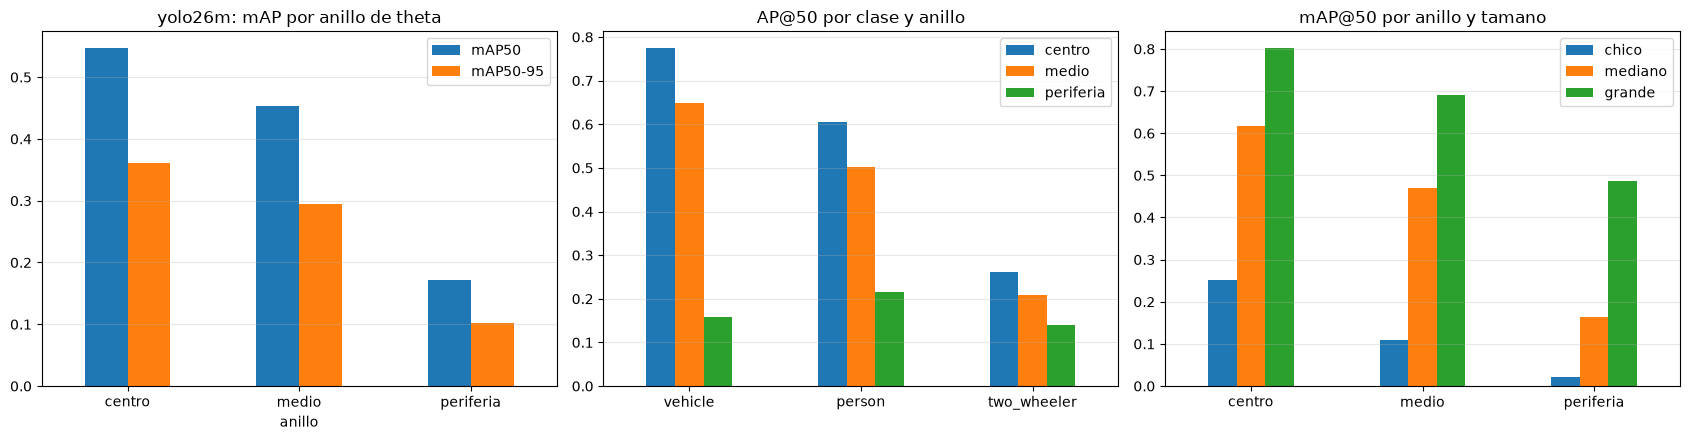

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.5))
res_theta.loc[NOMBRES_ANILLOS, ["mAP50", "mAP50-95"]].plot.bar(ax=axs[0], rot=0)
axs[0].set_title(f"{MODELO}: mAP por anillo de theta")
por_clase[NOMBRES_ANILLOS].plot.bar(ax=axs[1], rot=0)
axs[1].set_title("AP@50 por clase y anillo")
cruce.plot.bar(ax=axs[2], rot=0)
axs[2].set_title("mAP@50 por anillo y tamano")
for ax in axs:
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(SALIDAS / f"metricas_{MODELO}.png", dpi=150)
plt.show()

#### Por cámara

Las laterales (MVL, MVR) miran hacia abajo y ven casi todo en la periferia, la frontal y la trasera tienen la calle en el centro.

In [16]:
por_cam = pd.DataFrame({cam: dict(zip(["mAP50", "mAP50-95"], evaluar(p, test[test["camera"] == cam])))
                        for cam in sorted(test["camera"].unique())}).T
por_cam.to_csv(SALIDAS / f"por_camara_{MODELO}.csv")
por_cam.round(3)

,mAP50,mAP50-95
FV,0.543,0.354
MVL,0.279,0.174
MVR,0.281,0.178
RV,0.508,0.328


#### Latencia

Media y percentiles de la inferencia por imagen. La comparación de latencia entre ramas solo vale si se mide en la misma máquina (pendiente del equipo), así que dejo anotado el hardware.

In [17]:
lat = p[["ms_inf", "ms_post"]].describe(percentiles=[0.5, 0.95]).T[["mean", "50%", "95%"]]
lat.loc["total"] = (p["ms_inf"] + p["ms_post"]).describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%"]].values
print(f"hardware: {gpu} | fps medio: {1e3 / lat.loc['total', 'mean']:.1f}")
lat.round(2)

hardware: NVIDIA GeForce RTX 4080 SUPER | fps medio: 85.0


,mean,50%,95%
ms_inf,11.67,11.64,12.12
ms_post,0.10,0.09,0.11
total,11.76,11.74,12.22


Por último guardo la tabla en el mismo formato que `tabla_resultados` de la rama 2 (una fila por modelo), así se pueden concatenar los `resultados.csv` de las ramas.

In [18]:
resultados = tabla_resultados(preds, test, por="theta")
resultados.to_csv(SALIDAS / "resultados.csv")
resultados.round(3)

,mAP50,mAP50-95,mAP50 centro,mAP50-95 centro,mAP50 medio,mAP50-95 medio,mAP50 periferia,mAP50-95 periferia,ms_inf,ms_post,ms_total,fps
modelo,,,,,,,,,,,,
yolo26m,0.394,0.252,0.547,0.36,0.453,0.295,0.171,0.102,11.666,0.095,11.762,85.023


### Conclusiones

Resultados sobre el test completo, 1000 imágenes (247 FV, 251 MVL, 261 MVR y 241 RV) con 11.910 cajas, YOLO26m pre-entrenado en COCO, `imgsz=640`, en una RTX 4080 SUPER.

**La degradación hacia la periferia es fuerte y es el número a batir.** El mAP@50 cae de 0,547 en el centro (θ < 68,3°) a 0,453 en el anillo medio y a 0,171 en la periferia (θ > 80,7°), una pérdida del 69% entre centro y periferia. En mAP@50-95 la caída es del 72% (0,361 → 0,102). Globalmente el modelo logra 0,394 de mAP@50 y 0,252 de mAP@50-95.

**YOLO26m mejora poco sobre YOLOv8m y no cambia el panorama.** Contra el baseline preliminar del equipo, YOLO26m sube el mAP@50 global de 0,374 a 0,394 y el mAP@50-95 de 0,230 a 0,252, pero en la periferia apenas pasa de 0,164 a 0,171. Cambiar a un modelo más nuevo mejora el centro y deja la periferia casi igual: el problema no se arregla con un mejor detector genérico, que es lo que motiva las ramas 2 a 4.

**La caída es geométrica, no solo de escala.** Separando por tamaño de objeto (rangos de área de COCO), la degradación persiste dentro de cada rango: los objetos grandes pasan de 0,802 en el centro a 0,486 en la periferia, los medianos de 0,618 a 0,164 y los chicos de 0,252 a 0,021. La pérdida relativa es del 39% en grandes y del 92% en chicos, o sea que la deformación es más destructiva cuantos menos píxeles describen al objeto.

**`vehicle` es la clase que más pierde.** Su AP@50 baja de 0,774 en el centro a 0,159 en la periferia (−79%), mientras que `person` baja de 0,605 a 0,215 y `two_wheeler` de 0,262 a 0,140. Los autos estacionados a los costados de las laterales quedan muy estirados y curvados en la periferia, lejos de cualquier auto de COCO. `two_wheeler` rinde bajo en todos los anillos, como ya había notado el equipo.

**Las cámaras laterales son las más afectadas.** FV y RV logran 0,543 y 0,508 de mAP@50, MVL y MVR solo 0,279 y 0,281. Las laterales miran hacia abajo y ven la calle casi entera en la periferia. En las visualizaciones aparecen además falsos `vehicle` del tamaño de la imagen sobre la carrocería propia, que una máscara del ego-vehículo eliminaría.

**Latencia.** 11,7 ms por imagen de media (p95 12,2 ms), unos 85 FPS en la RTX 4080 SUPER, sin preprocesamiento. Es la cota inferior de latencia de las cuatro ramas, porque las ramas 2 y 4 suman el `remap` y la reproyección de cajas. Para comparar latencias, las cuatro ramas tienen que medirse en la misma máquina.

Las predicciones quedan en `outputs/rama1/` (`preds_yolo26m_1000.pkl` y `pred_yolo26m.json`) y las tablas en CSV, para que las otras ramas puedan compararse sin volver a correr esta.